<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/BA820_Team6_Project_M2_Xiaoxuan_Zhu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA for Research Question 1: Movement Behavior Profiles Among Cats

This notebook supports Milestone 2 and focuses on the first research question from the project proposal:
whether distinct outdoor movement behavior profiles can be identified among cats in terms of
movement intensity, temporal activity patterns, and spatial roaming ranges.

Rather than focusing on isolated extreme events, the goal of this analysis is to examine
cat-level behavioral patterns constructed across multiple movement dimensions. The emphasis
is on identifying systematic differences across individuals that may reflect distinct
movement behavior profiles.

## 1. Data Loading & Cleaning

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cats_uk_reference.csv to cats_uk_reference.csv
Saving cats_uk.csv to cats_uk.csv


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'cats_uk_reference.csv', 'cats_uk.csv', 'sample_data']


In [ ]:
import pandas as pd

events = pd.read_csv("/content/cats_uk.csv")
ref    = pd.read_csv("/content/cats_uk_reference.csv")

print(events.shape)
print(ref.shape)

(18215, 11)
(101, 16)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Events columns:", events.columns.tolist())
print("Ref columns   :", ref.columns.tolist())

Events columns: ['tag_id', 'event_id', 'visible', 'timestamp', 'location_long', 'location_lat', 'ground_speed', 'height_above_ellipsoid', 'algorithm_marked_outlier', 'manually_marked_outlier', 'study_name']
Ref columns   : ['tag_id', 'animal_id', 'animal_taxon', 'deploy_on_date', 'deploy_off_date', 'hunt', 'prey_p_month', 'animal_reproductive_condition', 'animal_sex', 'hrs_indoors', 'n_cats', 'food_dry', 'food_wet', 'food_other', 'study_site', 'age_years']


In [ ]:
print("Events columns:")
events.columns.tolist()

Events columns:


['tag_id',
 'event_id',
 'visible',
 'timestamp',
 'location_long',
 'location_lat',
 'ground_speed',
 'height_above_ellipsoid',
 'algorithm_marked_outlier',
 'manually_marked_outlier',
 'study_name']

In [ ]:
COL = {
    "cat_id": "tag_id",
    "timestamp": "timestamp",
    "speed": "ground_speed",
    "lat": "location_lat",
    "lon": "location_long"
}

In [ ]:
df = events.copy()
print(df.shape)
df.head()

(18215, 11)


,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


In [ ]:
df = df.dropna(subset=[COL["cat_id"], COL["speed"]])

df[COL["speed"]] = pd.to_numeric(df[COL["speed"]], errors="coerce")
df = df.dropna(subset=[COL["speed"]])

df = df[df[COL["speed"]] >= 0]

print("After minimal cleaning:", df.shape)

After minimal cleaning: (18215, 11)


## 2. EDA Step 1: GPS Sampling Imbalance

In [ ]:
obs_count = (
    df.groupby(COL["cat_id"])
      .size()
      .reset_index(name="n_obs")
)

obs_count.describe()


,n_obs
count,101.000000
mean,180.346535
std,146.280582
min,12.000000
25%,100.000000
50%,155.000000
75%,214.000000
max,963.000000


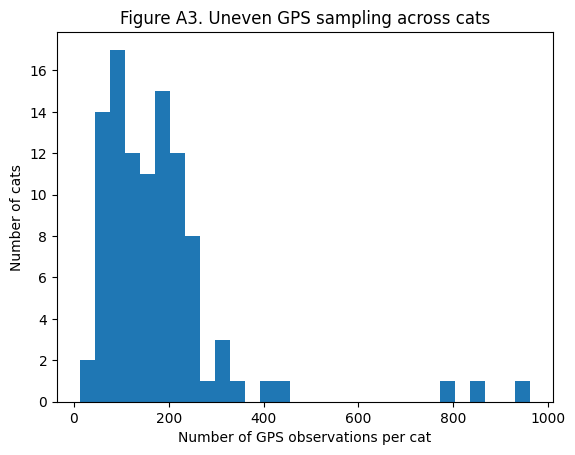

In [ ]:
plt.figure()
plt.hist(obs_count["n_obs"], bins=30)
plt.xlabel("Number of GPS observations per cat")
plt.ylabel("Number of cats")
plt.title("Figure A3. Uneven GPS sampling across cats")
plt.show()

Before analyzing movement behavior, I assess GPS sampling coverage across individual cats.
The number of observations varies substantially, indicating that some cats are tracked much
more frequently than others.

This imbalance motivates the use of cat-level aggregated features rather than raw GPS points.
By aggregating observations a aim to construct comparable
behavioral summaries that better reflect stable movement profiles across cats.

## 3. EDA Step 2: Distribution of Movement Speed


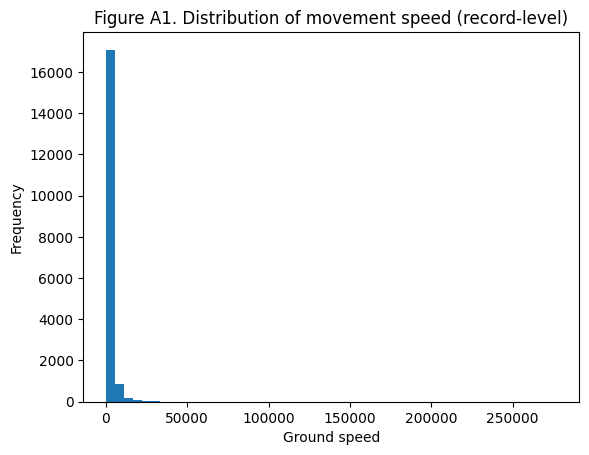

In [ ]:
plt.figure()
plt.hist(df[COL["speed"]], bins=50)
plt.xlabel("Ground speed")
plt.ylabel("Frequency")
plt.title("Figure A1. Distribution of movement speed (record-level)")
plt.show()

The distribution of ground speed is highly right-skewed, with most observations occurring
at low speeds and a smaller number of higher-speed movements.

This distribution suggests that average-based summaries alone may be insufficient to
characterize movement behavior. Instead, multiple complementary measures are needed to
capture heterogeneity in movement intensity across cats.

## 4. EDA Step 3: Concentration of Extreme Movement

In [ ]:
cat_max_speed = (
    df.groupby(COL["cat_id"])[COL["speed"]]
      .max()
      .reset_index(name="max_speed")
)

cat_max_speed.describe()

,max_speed
count,101.000000
mean,25251.683168
std,32892.958836
min,6264.000000
25%,12780.000000
50%,18720.000000
75%,26316.000000
max,277092.000000


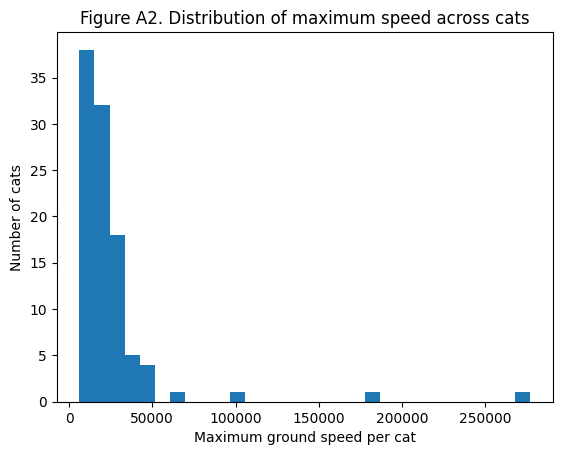

In [ ]:
plt.figure()
plt.hist(cat_max_speed["max_speed"], bins=30)
plt.xlabel("Maximum ground speed per cat")
plt.ylabel("Number of cats")
plt.title("Figure A2. Distribution of maximum speed across cats")
plt.show()

Comparing mean and maximum speed at the individual level shows that cats with similar
average movement intensity can differ substantially in other aspects of movement behavior.

This observation reinforces the limitation of relying on a single summary statistic and
motivates the use of multiple features to distinguish movement behavior profiles.

## 5. EDA Step 4: Mean vs Max Speed

In [ ]:
cat_speed_summary = (
    df.groupby(COL["cat_id"])[COL["speed"]]
      .agg(mean_speed="mean", max_speed="max", median_speed="median")
      .reset_index()
)

cat_speed_summary.head()

,tag_id,mean_speed,max_speed,median_speed
0,Abba-Tag,1603.951807,13968,864.0
1,Alfie-Tag,1931.679144,14652,1188.0
2,Amber-Tag,1967.614679,21888,1188.0
3,Ares,2285.825243,14328,1440.0
4,Athena,2134.188679,19728,1494.0


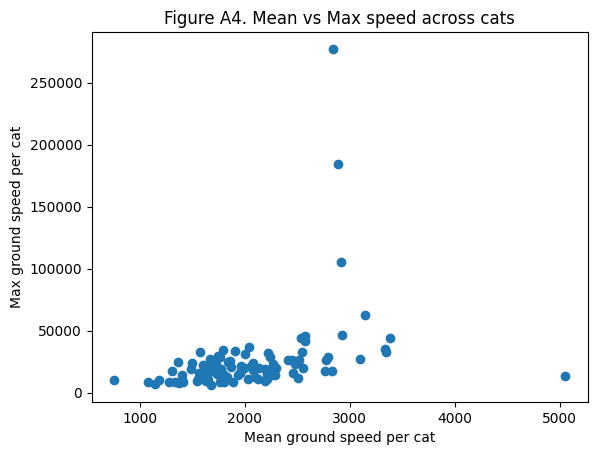

In [ ]:
plt.figure()
plt.scatter(cat_speed_summary["mean_speed"],
            cat_speed_summary["max_speed"])
plt.xlabel("Mean ground speed per cat")
plt.ylabel("Max ground speed per cat")
plt.title("Figure A4. Mean vs Max speed across cats")
plt.show()

Spatial roaming proxies based on latitude and longitude spans provide an interpretable
measure of how widely individual cats range outdoors.

The distribution of these measures reveals substantial heterogeneity in spatial behavior,
with some cats exhibiting highly localized movement and others covering much broader areas.
These differences are a key dimension of movement behavior profiles.

## 6. EDA Step 5: Temporal Activity Patterns

In [ ]:
# Parse timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour

# Define day vs night (example definition)
df["is_day"] = df["hour"].between(6, 18)

temporal = (
    df.groupby("tag_id")
    .agg(
        day_obs=("is_day", "sum"),
        total_obs=("is_day", "count")
    )
)

temporal["day_ratio"] = temporal["day_obs"] / temporal["total_obs"]
temporal.head()

,day_obs,total_obs,day_ratio
tag_id,,,
Abba-Tag,30,83,0.361446
Alfie-Tag,86,187,0.459893
Amber-Tag,161,218,0.738532
Ares,22,103,0.213592
Athena,48,106,0.452830


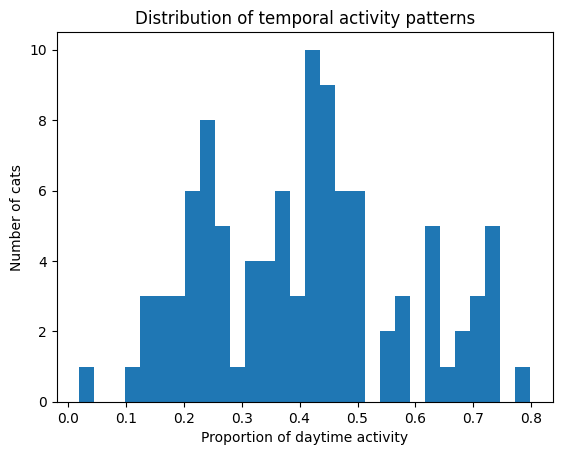

In [ ]:
plt.hist(temporal["day_ratio"], bins=30)
plt.xlabel("Proportion of daytime activity")
plt.ylabel("Number of cats")
plt.title("Distribution of temporal activity patterns")
plt.show()

As a simple proxy for spatial roaming behavior, I compute per-cat latitude and longitude spans
based on GPS coordinates. These measures provide an interpretable indicator of how widely cats
range spatially without requiring detailed distance calculations.

The distribution of roaming proxies further supports the presence of substantial heterogeneity
in spatial activity across individuals.

## 7. Preprocessing Decisions

Several preprocessing decisions were made based on insights from the exploratory data
analysis. First, due to substantial imbalance in the number of GPS observations across
cats, all analyses are conducted using cat-level aggregated features rather than raw
GPS points. This ensures comparability across individuals and prevents heavily sampled
cats from dominating the analysis.

Second, movement intensity features are summarized using robust statistics (mean,
median, and 75th percentile) rather than extreme values, as the goal is to characterize
overall movement behavior profiles rather than isolated rare events.

Third, simple spatial roaming proxies based on latitude and longitude spans are used to
capture differences in spatial extent in an interpretable manner at this exploratory
stage. Finally, all features are standardized prior to clustering to account for scale
differences and to ensure that no single dimension dominates the distance-based methods.

## 8. Feature Construction & Scaling

,cat_id,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio
0,Abba-Tag,1603.951807,864.0,1746.0,0.003963,0.010782,0.361446
1,Alfie-Tag,1931.679144,1188.0,2358.0,0.004066,0.012550,0.459893
2,Amber-Tag,1967.614679,1188.0,2475.0,0.030289,0.040155,0.738532
3,Ares,2285.825243,1440.0,2898.0,0.002487,0.003378,0.213592
4,Athena,2134.188679,1494.0,2862.0,0.002319,0.003988,0.452830


Feature table shape: (101, 7)
Scaled matrix shape: (101, 6)


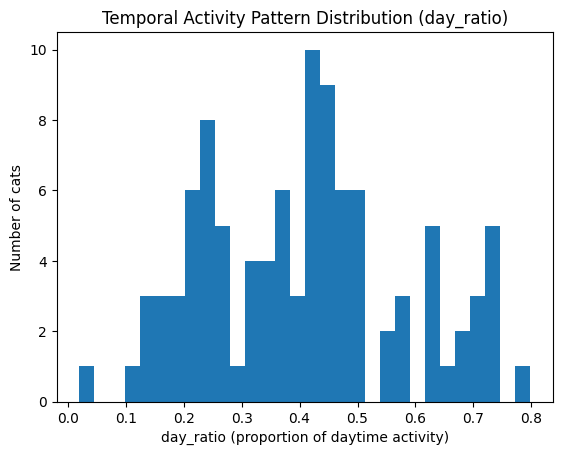

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = events.copy()

df = df.dropna(subset=["tag_id", "timestamp", "ground_speed", "location_lat", "location_long"])
df["ground_speed"] = pd.to_numeric(df["ground_speed"], errors="coerce")
df = df.dropna(subset=["ground_speed"])
df = df[df["ground_speed"] >= 0]

speed_g = df.groupby("tag_id")["ground_speed"]
speed_features = pd.DataFrame({
    "mean_speed": speed_g.mean(),
    "median_speed": speed_g.median()
    "p75_speed": speed_g.quantile(0.75),
})

loc_g = df.groupby("tag_id")
spatial_features = pd.DataFrame({
    "lat_span": loc_g["location_lat"].max() - loc_g["location_lat"].min(),
    "lon_span": loc_g["location_long"].max() - loc_g["location_long"].min(),
})

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])
df["hour"] = df["timestamp"].dt.hour

df["is_day"] = df["hour"].between(6, 18)

temporal = (
    df.groupby("tag_id")
      .agg(day_obs=("is_day", "sum"), total_obs=("is_day", "count"))
)
temporal["day_ratio"] = temporal["day_obs"] / temporal["total_obs"]

features = (
    speed_features[["mean_speed", "median_speed", "p75_speed"]]
      .join(spatial_features)
      .join(temporal[["day_ratio"]])
      .reset_index()
      .rename(columns={"tag_id": "cat_id"})
)

display(features.head())
print("Feature table shape:", features.shape)

X = features.drop(columns=["cat_id"]).copy()
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median())

for col in ["lat_span", "lon_span"]:
    if col in X.columns:
        X[col] = np.log1p(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled matrix shape:", X_scaled.shape)

plt.figure()
plt.hist(temporal["day_ratio"], bins=30)
plt.xlabel("day_ratio (proportion of daytime activity)")
plt.ylabel("Number of cats")
plt.title("Temporal Activity Pattern Distribution (day_ratio)")
plt.show()

## 8. Method 1: KMeans (K=2/3/4)

KMeans k=2: inertia=440.54, silhouette=0.684
KMeans k=3: inertia=303.95, silhouette=0.337
KMeans k=4: inertia=223.05, silhouette=0.313


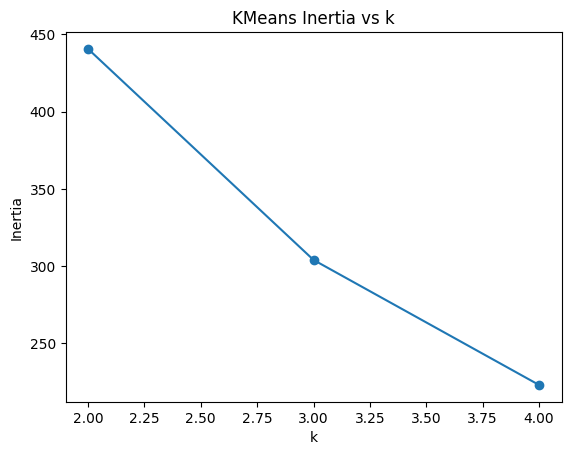

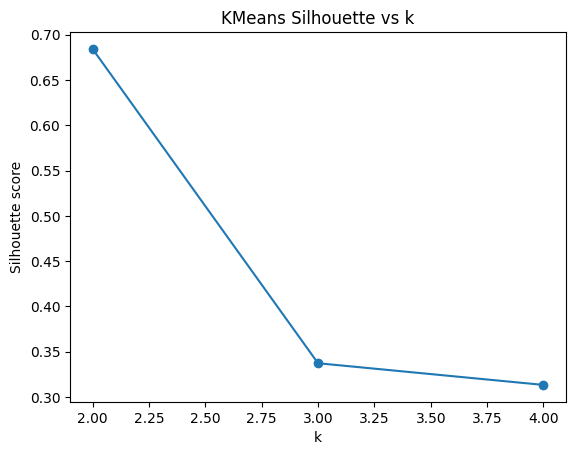

Best k by silhouette: 2
Cluster sizes:
kmeans_cluster
0    98
1     3
Name: count, dtype: int64


,cat_id,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio,kmeans_cluster,hier_cluster
0,Abba-Tag,1603.951807,864.0,1746.0,0.003963,0.010782,0.361446,0,2
1,Alfie-Tag,1931.679144,1188.0,2358.0,0.004066,0.012550,0.459893,0,0
2,Amber-Tag,1967.614679,1188.0,2475.0,0.030289,0.040155,0.738532,0,2
3,Ares,2285.825243,1440.0,2898.0,0.002487,0.003378,0.213592,0,0
4,Athena,2134.188679,1494.0,2862.0,0.002319,0.003988,0.452830,0,0


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = [2, 3, 4]
inertias = []
silhouettes = []
kmeans_labels = {}

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    kmeans_labels[k] = labels
    print(f"KMeans k={k}: inertia={km.inertia_:.2f}, silhouette={silhouettes[-1]:.3f}")

plt.figure()
plt.plot(ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("KMeans Inertia vs k")
plt.show()

plt.figure()
plt.plot(ks, silhouettes, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("KMeans Silhouette vs k")
plt.show()

best_k = ks[int(np.argmax(silhouettes))]
print("Best k by silhouette:", best_k)

k_chosen = best_k
features["kmeans_cluster"] = kmeans_labels[k_chosen]

print("Cluster sizes:")
print(features["kmeans_cluster"].value_counts().sort_index())
display(features.head())

In [ ]:
profile_cols = ["mean_speed", "median_speed", "p75_speed", "lat_span", "lon_span", "day_ratio"]
cluster_profile = (
    features.groupby("kmeans_cluster")[profile_cols]
            .median()
            .sort_index()
)

display(cluster_profile)

for c in sorted(features["kmeans_cluster"].unique()):
    print("\n--- Cluster", c, "examples ---")
    display(
        features[features["kmeans_cluster"] == c]
        .sort_values(["lat_span", "mean_speed"], ascending=False)
        .head(5)
    )

,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio
kmeans_cluster,,,,,,
0,1893.807577,1152.0,2232.0,0.004118,0.004911,0.418011
1,2541.568966,972.0,2268.0,0.369648,0.315137,0.623053



--- Cluster 0 examples ---


,cat_id,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio,kmeans_cluster
29,Fairclough-Tag,2538.285714,1008.0,2016.0,0.080654,0.092268,0.452381,0
49,Jim-Tag,2883.934426,1296.0,2466.0,0.079510,0.052025,0.442623,0
38,Gracie-Tag,2924.674699,1044.0,3528.0,0.053226,0.020414,0.650602,0
61,Marley-Tag,1564.338462,972.0,2016.0,0.043106,0.037285,0.430769,0
26,Dory-Tag,2225.000000,1080.0,2700.0,0.041466,0.017957,0.430556,0



--- Cluster 1 examples ---


,cat_id,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio,kmeans_cluster
67,Mifty-Tag,1367.862069,828.0,1872.0,0.434002,0.693840,0.467433,1
25,Dexter2-Tag,2541.568966,1368.0,2889.0,0.369648,0.315137,0.625000,1
39,Gracie_2-Tag,2834.803738,972.0,2268.0,0.152103,0.220593,0.623053,1


## 9. Method 2: Hierarchical

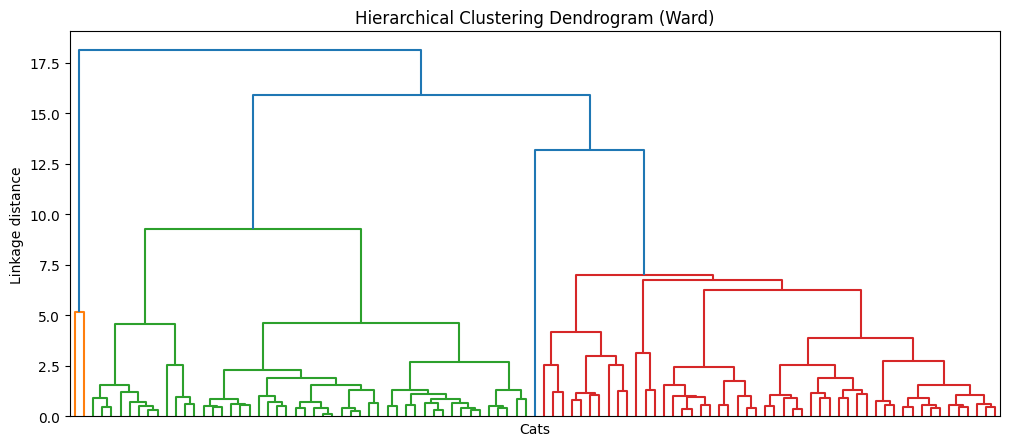

Hierarchical (Ward) clusters=2: silhouette=0.733, sizes={0: 99, 1: 2}
Hierarchical (Ward) clusters=3: silhouette=0.283, sizes={0: 51, 2: 48, 1: 2}
Hierarchical (Ward) clusters=4: silhouette=0.291, sizes={2: 50, 0: 48, 1: 2, 3: 1}
Hierarchical cluster sizes:
hier_cluster
0    51
1     2
2    48
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score
import pandas as pd

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Cats")
plt.ylabel("Linkage distance")
plt.show()

for n_clusters in [2, 3, 4]:
    agg = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sizes = pd.Series(labels).value_counts().to_dict()
    print(f"Hierarchical (Ward) clusters={n_clusters}: silhouette={sil:.3f}, sizes={sizes}")

h_chosen = 3
agg = AgglomerativeClustering(n_clusters=h_chosen, linkage="ward")
features["hier_cluster"] = agg.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
print(features["hier_cluster"].value_counts().sort_index())

## 10. Summary of Clustering Experiments

In [ ]:
k_profile = features.groupby("kmeans_cluster")[profile_cols].median()
h_profile = features.groupby("hier_cluster")[profile_cols].median()

print("KMeans profile (median):")
display(k_profile.sort_index())

print("Hierarchical profile (median):")
display(h_profile.sort_index())

KMeans profile (median):


,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio
kmeans_cluster,,,,,,
0,1893.807577,1152.0,2232.0,0.004118,0.004911,0.418011
1,2541.568966,972.0,2268.0,0.369648,0.315137,0.623053


Hierarchical profile (median):


,mean_speed,median_speed,p75_speed,lat_span,lon_span,day_ratio
hier_cluster,,,,,,
0,2285.825243,1404.0,2628.0,0.005269,0.006330,0.430556
1,1954.715517,1098.0,2380.5,0.401825,0.504489,0.546216
2,1623.847181,972.0,1998.0,0.004005,0.004523,0.392911
